## Gerekli Kütüphaneleri İçe Aktarma

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score)

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')
import warnings
warnings.filterwarnings('ignore')

## Veri Yolu (Colab / Google Drive)

Colab'da çalışıyorsan aşağıdaki üç satırın başındaki `#` işaretlerini kaldır ve `VERI_KLASORU`'nu dosyanın Drive'daki klasörüne göre düzenle.

In [1]:
# --- GOOGLE COLAB + DRIVE KULLANIYORSAN bu üç satırın başındaki # işaretlerini sil: ---
# from google.colab import drive
# drive.mount('/content/drive')
# VERI_KLASORU = "/content/drive/MyDrive/SoftITO"   # csv'nin Drive'daki klasörü

# Bilgisayarda ya da dosya notebook ile aynı klasördeyse:
VERI_KLASORU = "."


## 2. Veriyi Yükleme ve Keşfetme

In [3]:
df = pd.read_csv(f"{VERI_KLASORU}/diabetes_012_health_indicators_BRFSS2015.csv")
print("Boyut:", df.shape)
df.head()

Boyut: (253680, 22)


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [4]:
# Hedef değişkenin dağılımı: 0 = sağlıklı, 1 = prediyabet, 2 = diyabet
print(df["Diabetes_012"].value_counts())
print()
print("Eksik değer:", df.isnull().sum().sum())
print("Duplicate satır:", df.duplicated().sum())

Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64

Eksik değer: 0


Duplicate satır: 23899


**İki gözlem, iki karar:**

1. **Duplicate'ler hakkında:** ~24 bin "aynı" satır var ama bu veri setinde kişi kimliği (ID) yok ve
   22 sütunun neredeyse tamamı kategorik/tam sayı. 253 bin kişilik bir ankette iki farklı kişinin
   bütün sorulara aynı cevabı vermesi gayet olası. Bu yüzden bunları **silmiyoruz** — pandas
   derslerindeki ilke burada da geçerli: *her tekrar, hata değildir; karar veriye göre verilir.*

2. **Hedefi ikili yapıyoruz:** Ders ikili (binary) sınıflandırma üzerineydi. Prediyabet (1) klinik
   olarak diyabet yolunda bir risk durumu olduğundan, 1 ve 2'yi birleştirip
   **"diyabet riski var (1) / yok (0)"** hedefi tanımlıyoruz.

In [5]:
# İkili hedef: 0 -> 0 (sağlıklı), 1 ve 2 -> 1 (diyabet/prediyabet)
df["Diyabet"] = (df["Diabetes_012"] > 0).astype(int)

oran = df["Diyabet"].value_counts(normalize=True)
print(df["Diyabet"].value_counts())
print(f"\nPozitif sınıf oranı: %{oran[1]*100:.1f}  <- SINIF DENGESİZLİĞİ! Bunu unutmayacağız.")

Diyabet
0    213703
1     39977
Name: count, dtype: int64

Pozitif sınıf oranı: %15.8  <- SINIF DENGESİZLİĞİ! Bunu unutmayacağız.


In [6]:
# Hangi özellikler diyabetle en ilişkili? (nokta biserial korelasyon ~ Pearson ile)
ozellikler = [c for c in df.columns if c not in ["Diabetes_012", "Diyabet"]]
korelasyon = df[ozellikler + ["Diyabet"]].corr()["Diyabet"].drop("Diyabet").sort_values(ascending=False)
print("Diyabet ile korelasyonlar (ilk 8 ve son 3):")
print(korelasyon.head(8).round(3))
print("...")
print(korelasyon.tail(3).round(3))

Diyabet ile korelasyonlar (ilk 8 ve son 3):
GenHlth                 0.301
HighBP                  0.270
BMI                     0.224
DiffWalk                0.222
HighChol                0.210
Age                     0.186
HeartDiseaseorAttack    0.177
PhysHlth                0.175
Name: Diyabet, dtype: float64
...
PhysActivity   -0.121
Education      -0.132
Income         -0.173
Name: Diyabet, dtype: float64


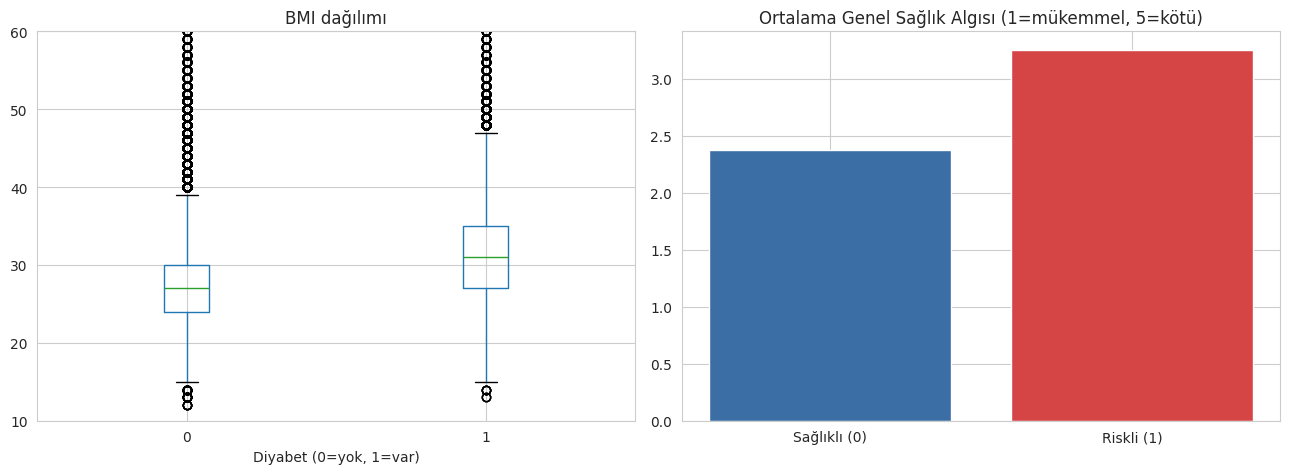

In [7]:
# Görsel keşif: iki güçlü aday özelliğin gruplara göre farkı
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df.boxplot(column="BMI", by="Diyabet", ax=axes[0])
axes[0].set_title("BMI dağılımı"); axes[0].set_xlabel("Diyabet (0=yok, 1=var)")
axes[0].set_ylim(10, 60)

gh = df.groupby("Diyabet")["GenHlth"].mean()
axes[1].bar(["Sağlıklı (0)", "Riskli (1)"], gh.values, color=["#3b6ea5", "#d64545"])
axes[1].set_title("Ortalama Genel Sağlık Algısı (1=mükemmel, 5=kötü)")
plt.suptitle("")
plt.tight_layout()
plt.show()

## 3. Özellik/Hedef Ayrımı ve Train/Test

Dengesiz veri setlerinde ayrımı `stratify` ile yapıyoruz ki her iki sette de sınıf oranları korunusun
(dersin train/test adımına dengesizlik nedeniyle eklediğimiz güvence).

In [8]:
X = df[ozellikler]
y = df["Diyabet"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Eğitim: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Eğitimde pozitif oranı: %{y_train.mean()*100:.1f} | Testte: %{y_test.mean()*100:.1f}")

Eğitim: 202944 | Test: 50736
Eğitimde pozitif oranı: %15.8 | Testte: %15.8


## 4. Özellik Ölçeklendirme (StandardScaler)

Dersteki kritik kural: **scaler yalnızca eğitim verisine fit edilir**, test verisi aynı dönüşümle
sadece transform edilir — aksi test bilgisinin modele sızması (data leakage) olur.

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform: SADECE eğitim
X_test_scaled  = scaler.transform(X_test)        # sadece transform: test

print("Ölçekleme sonrası eğitim ortalamaları ~0:", X_train_scaled.mean(axis=0)[:4].round(3))
print("Ölçekleme sonrası eğitim std'leri   ~1:", X_train_scaled.std(axis=0)[:4].round(3))

Ölçekleme sonrası eğitim ortalamaları ~0: [-0. -0.  0. -0.]
Ölçekleme sonrası eğitim std'leri   ~1: [1. 1. 1. 1.]


## 5. Model 1: Standart Lojistik Regresyon

In [10]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print(f"Doğruluk (accuracy): {accuracy_score(y_test, y_pred):.4f}")

Doğruluk (accuracy): 0.8481


%85 doğruluk — kulağa harika geliyor, değil mi? **Ama durun.** Veri setinin %84'ü zaten sağlıklı;
herkese "sağlıklı" diyen kafasız bir model bile %84 doğruluk alırdı. Yani modelimiz o kafasız
modelden neredeyse hiç iyi değil! Gerçeği karmaşıklık matrisi söyler.

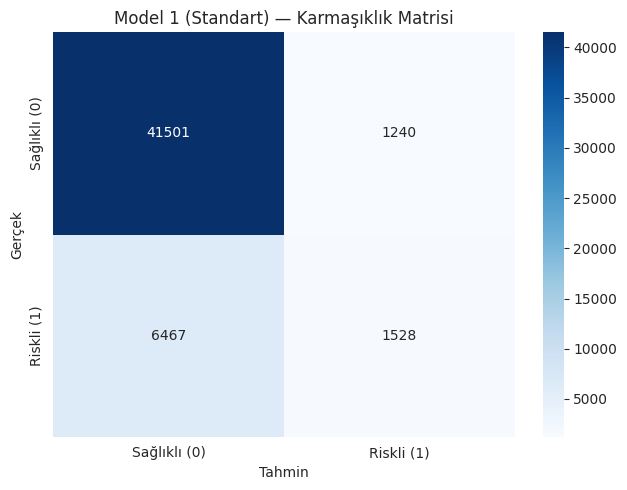

              precision    recall  f1-score   support

    Sağlıklı       0.87      0.97      0.92     42741
      Riskli       0.55      0.19      0.28      7995

    accuracy                           0.85     50736
   macro avg       0.71      0.58      0.60     50736
weighted avg       0.82      0.85      0.82     50736



In [11]:
# Karmaşıklık matrisi
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6.5, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Sağlıklı (0)", "Riskli (1)"],
            yticklabels=["Sağlıklı (0)", "Riskli (1)"])
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("Model 1 (Standart) — Karmaşıklık Matrisi")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=["Sağlıklı", "Riskli"]))

**İşte yanılsama ortaya çıktı:** Model, gerçekten riskli olan hastaların yalnızca **%19'unu**
yakalayabiliyor (recall). Yani 100 diyabet riskli kişiden ~81'ine "sağlıklısın" diyor! Sağlık
taramasında bu kabul edilemez — kaçırılan hasta (false negative), yanlış alarm verilen sağlıklıdan
(false positive) çok daha maliyetlidir.

## 6. Model 2: Sınıf Ağırlıklı Lojistik Regresyon

`class_weight="balanced"` azınlık sınıfının hatalarını daha ağır cezalandırır — model artık
riskli sınıfı ciddiye almak zorunda.

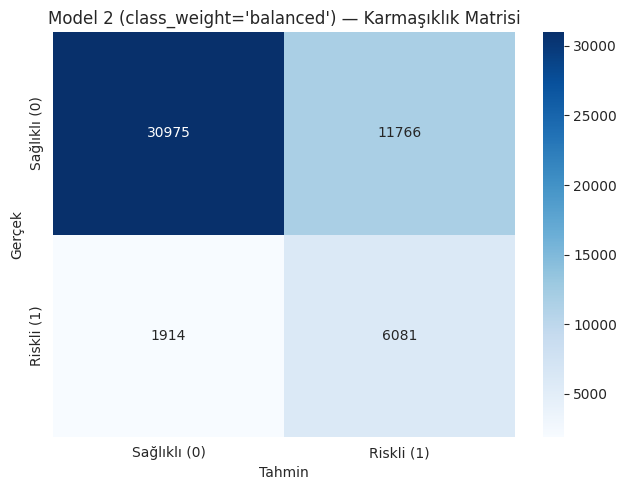

              precision    recall  f1-score   support

    Sağlıklı       0.94      0.72      0.82     42741
      Riskli       0.34      0.76      0.47      7995

    accuracy                           0.73     50736
   macro avg       0.64      0.74      0.64     50736
weighted avg       0.85      0.73      0.76     50736



In [12]:
model_dengeli = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
model_dengeli.fit(X_train_scaled, y_train)
y_pred_d = model_dengeli.predict(X_test_scaled)

cm_d = confusion_matrix(y_test, y_pred_d)
plt.figure(figsize=(6.5, 5))
sns.heatmap(cm_d, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Sağlıklı (0)", "Riskli (1)"],
            yticklabels=["Sağlıklı (0)", "Riskli (1)"])
plt.xlabel("Tahmin"); plt.ylabel("Gerçek")
plt.title("Model 2 (class_weight='balanced') — Karmaşıklık Matrisi")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_d, target_names=["Sağlıklı", "Riskli"]))

In [13]:
# İki modelin yan yana karşılaştırması (Riskli sınıf odaklı)
karsilastirma = pd.DataFrame({
    "Model": ["Standart", "class_weight='balanced'"],
    "Accuracy": [accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred_d)],
    "Precision (Riskli)": [precision_score(y_test, y_pred), precision_score(y_test, y_pred_d)],
    "Recall (Riskli)": [recall_score(y_test, y_pred), recall_score(y_test, y_pred_d)],
    "F1 (Riskli)": [f1_score(y_test, y_pred), f1_score(y_test, y_pred_d)],
}).round(3)
karsilastirma

,Model,Accuracy,Precision (Riskli),Recall (Riskli),F1 (Riskli)
0,Standart,0.848,0.552,0.191,0.284
1,class_weight='balanced',0.730,0.341,0.761,0.471


**Takas (trade-off) net görülüyor:** Dengeli model genel doğruluktan feragat etti ama riskli
hastaları yakalama oranını (recall) kat kat artırdı. Hangi model "daha iyi"? **Amaca bağlı:**
tarama amaçlı bir sistemde recall kritiktir → Model 2; kesin teşhis öncesi ön filtrede yanlış
alarm maliyetliyse precision önem kazanır. Metrik seçimi, iş probleminin kendisidir.

## 7. Katsayı Yorumu: Riski Ne Artırıyor?

Lojistik regresyonun güzelliği (dersteki vurgu): katsayılar yorumlanabilir. Pozitif katsayı riski
artırır, negatif azaltır. Özellikler ölçeklendiği için büyüklükleri adilce karşılaştırılabilir.

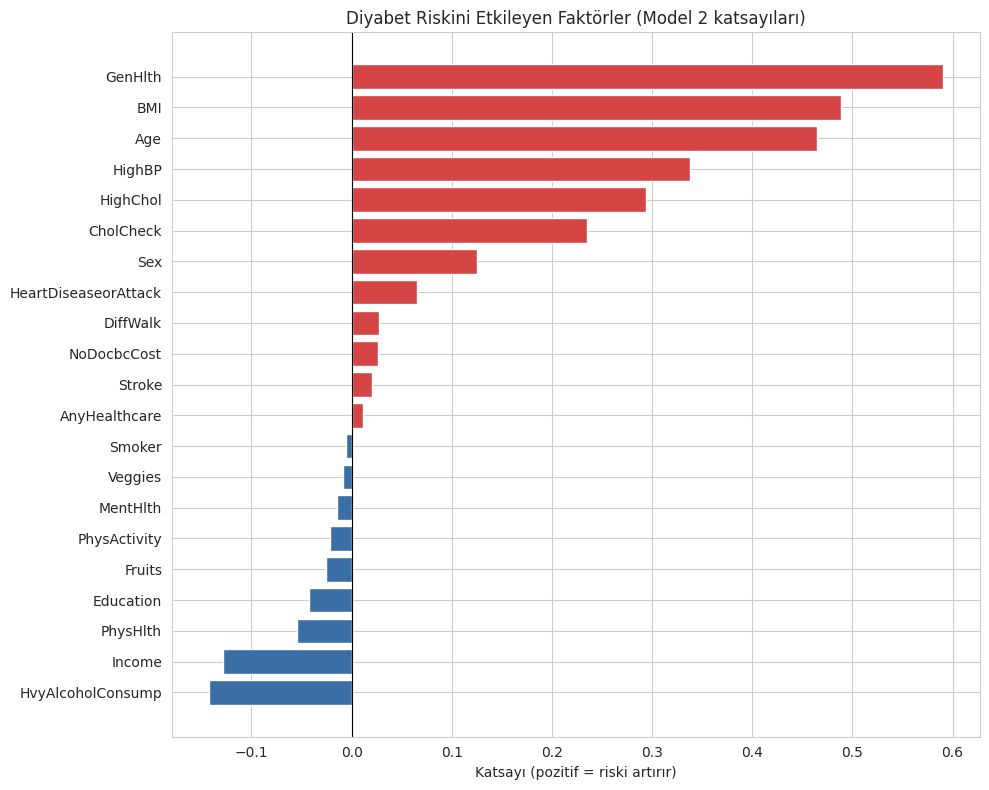

Riski en çok ARTIRAN 5 faktör:
 Ozellik  Katsayi
 GenHlth    0.591
     BMI    0.489
     Age    0.465
  HighBP    0.337
HighChol    0.294

Riski en çok AZALTAN 3 faktör:
          Ozellik  Katsayi
         PhysHlth   -0.055
           Income   -0.129
HvyAlcoholConsump   -0.143


In [14]:
katsayilar = pd.DataFrame({
    "Ozellik": ozellikler,
    "Katsayi": model_dengeli.coef_[0],
}).sort_values("Katsayi", ascending=False)

plt.figure(figsize=(10, 8))
renkler = ["#d64545" if k > 0 else "#3b6ea5" for k in katsayilar["Katsayi"]]
plt.barh(katsayilar["Ozellik"][::-1], katsayilar["Katsayi"][::-1],
         color=renkler[::-1])
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Katsayı (pozitif = riski artırır)")
plt.title("Diyabet Riskini Etkileyen Faktörler (Model 2 katsayıları)")
plt.tight_layout()
plt.show()

print("Riski en çok ARTIRAN 5 faktör:")
print(katsayilar.head(5).round(3).to_string(index=False))
print("\nRiski en çok AZALTAN 3 faktör:")
print(katsayilar.tail(3).round(3).to_string(index=False))

## 8. Örnek Tahmin (Olasılıklarıyla)

Dersteki gibi tek bir kişi için tahmin yapıyoruz — ama `predict_proba` ile sigmoid çıktısını,
yani **risk olasılığını** da gösteriyoruz.

In [15]:
# Test setinden iki örnek: modelin en emin olduğu bir riskli ve bir sağlıklı tahmin
proba = model_dengeli.predict_proba(X_test_scaled)[:, 1]   # 1 sınıfının olasılığı

en_riskli_idx  = proba.argmax()
en_sagliki_idx = proba.argmin()

for isim, idx in [("En yüksek riskli tahmin", en_riskli_idx), ("En düşük riskli tahmin", en_sagliki_idx)]:
    print(f"--- {isim} ---")
    kisi = X_test.iloc[idx]
    print(f"  BMI: {kisi['BMI']:.0f} | Yaş grubu: {kisi['Age']:.0f} | Yüksek tansiyon: {kisi['HighBP']:.0f}",
          f"| Yüksek kolesterol: {kisi['HighChol']:.0f} | Genel sağlık: {kisi['GenHlth']:.0f}")
    print(f"  Model olasılığı P(riskli) = {proba[idx]:.3f} | Gerçek etiket: {y_test.iloc[idx]}")
    print()

--- En yüksek riskli tahmin ---
  BMI: 87 | Yaş grubu: 7 | Yüksek tansiyon: 1 | Yüksek kolesterol: 1 | Genel sağlık: 5
  Model olasılığı P(riskli) = 0.998 | Gerçek etiket: 0

--- En düşük riskli tahmin ---
  BMI: 18 | Yaş grubu: 1 | Yüksek tansiyon: 0 | Yüksek kolesterol: 0 | Genel sağlık: 1
  Model olasılığı P(riskli) = 0.005 | Gerçek etiket: 0



## 9. Özet — Bu Pratikte Öğrendiklerim

1. **3 sınıflı hedef ikiliye dönüştürüldü** (prediyabet + diyabet = riskli) — gerekçesi açıklanarak
2. **Duplicate kararı veriye göre verildi:** ID'siz anket verisinde aynı cevap profilleri meşru → tutuldu
3. **Stratified train/test ayrımı** ile sınıf oranları her iki sette korundu
4. **StandardScaler doğru kullanıldı:** fit yalnızca eğitimde — data leakage önlendi
5. ⭐ **Doğruluk yanılsaması canlı yaşandı:** %85 accuracy'li model, riskli hastaların %81'ini kaçırıyordu;
   karmaşıklık matrisi ve classification_report gerçeği gösterdi
6. **class_weight='balanced'** ile recall kat kat artırıldı; precision-recall takasının iş problemine
   göre seçilmesi gerektiği anlaşıldı
7. **Katsayılar yorumlandı:** genel sağlık algısı, yüksek tansiyon, BMI ve kolesterol riski en çok
   artıran faktörler olarak öne çıktı
8. `predict_proba` ile sigmoidin ürettiği **risk olasılıkları** okundu

**Sonraki adım fikirleri:** karar eşiğini (0.5) oynayarak precision-recall eğrisi çıkarmak,
ROC-AUC ile modelleri eşikten bağımsız karşılaştırmak.

> ⚠️ **Not:** Bu bir eğitim çalışmasıdır; gerçek tıbbi teşhis ancak sağlık profesyonellerince konur.